<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/14_mediation-and-moderation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 14: Mediation

This homework assignment is designed to give you practice with mediation. You won't need to load in any data for this homework -- we'll simulate data instead.

---
## 1. Simulating data (3 points)


In this homework, we're going to simulate the relationship between age, word reading experience, and reading comprehension skill. Older children tend to be better at reading comprehension tasks, but this isn't just an inherent part of getting older. It's a combination of gaining more experience with reading, oral language skills, and executive functions development. In this homework, though, we're going to simplify this relationship down to a direct effect of age on reading comprehension (since improvements in oral language skills and executive functions are more guaranteed as children age than reading practice is), and a mediation of word reading experience.

In graphical form:
![picture](https://drive.google.com/uc?id=1wdm9xuiJhBJor99-9GnicO2_rzkGWtfN)

Writing the relationship out formally:

$$x = \beta_{xa} a + \beta_{x0} + \epsilon_{x}$$

$$c = \beta_{ca} a + \beta_{cx} x + \beta_{c0} + \epsilon_c$$



$c$ is reading comprehension, $x$ is word reading experience, and $a$ is age. $\beta_{c0}$ and $\beta_{x0}$ are intercept terms for their respective formulas, and $\epsilon_{c}$ and $\epsilon_{x}$ are gaussian noise terms. We'll start by writing a function, `simulate_data`, that can simulate this relationship. The input values are set and the function structure is provided below. Complete the function such that it takes in those input variables and generates $age$, $x$, and $c$ values. Use `runif()` to generate ages. Use `rnorm()` to generate the noise terms.

In [33]:
sample_size = 100 # How many children in data set?
age_lo = 80     # minimum age, in months
age_hi = 200    # maximum age, in months
beta_xa = 0.5   # amount by which experience changes for increase of one month in age
beta_x0 = -5    # amount of experience when age = 0 (not interpretable, since minimum age for this data is 80 months)
sd_x = 50       # standard dev of gaussian noise term, epsilon_x
beta_ca = 0.8   # amount that comprehension score improves for every increase of one unit in age
beta_cx = 3     # amount that comprehension score improves for every increase of one unit in reading experience
beta_c0 = 10    # comprehension score when reading experience is 0.
sd_c = 85      # standard dev of gaussian noise term, epsilon_c

simulate_data <- function(sample_size, age_lo, age_hi, beta_xa,
                          beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c) {
      # generates $age$, $x$, and $c$ values. Use runif() to generate ages. Use rnorm() to generate the noise terms

age <- runif(sample_size, min = age_lo, max = age_hi) # generate ages from 80-200 months
epsilon_x <- rnorm(sample_size, mean = 0 , sd = sd_x) # generate reading experience with gaussian noise term added as older aged kids have more experience reading thus better comprehension
x <- beta_xa * age  + beta_x0 + epsilon_x
epsilon_c <- rnorm(sample_size, mean = 0, sd = sd_c)
c <- beta_ca * age + beta_cx * x + beta_c0 + epsilon_c
  
  # Return as a data frame
  dat <- data.frame(age = age, x = x, c = c)
  return(dat)
}
    

In [19]:
dat <- simulate_data(sample_size, age_lo, age_hi, beta_xa, beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c)
head(dat)

,age,x,c
,<dbl>,<dbl>,<dbl>
1,100.4682,47.156506,272.9693
2,119.7459,-48.671613,130.9225
3,162.7715,107.558883,392.6006
4,175.5933,25.494823,202.2590
5,104.3698,52.827160,217.3409
6,146.5667,7.287735,249.7814


---
## 2. Visualizing Data (2 point)

Load the `tidyverse` library.

In [2]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### c is reading comprehension, x is word reading experience

a) Plot the relationship between age and reading comprehension.

In [21]:
library(ggplot2)

`geom_smooth()` using formula = 'y ~ x'


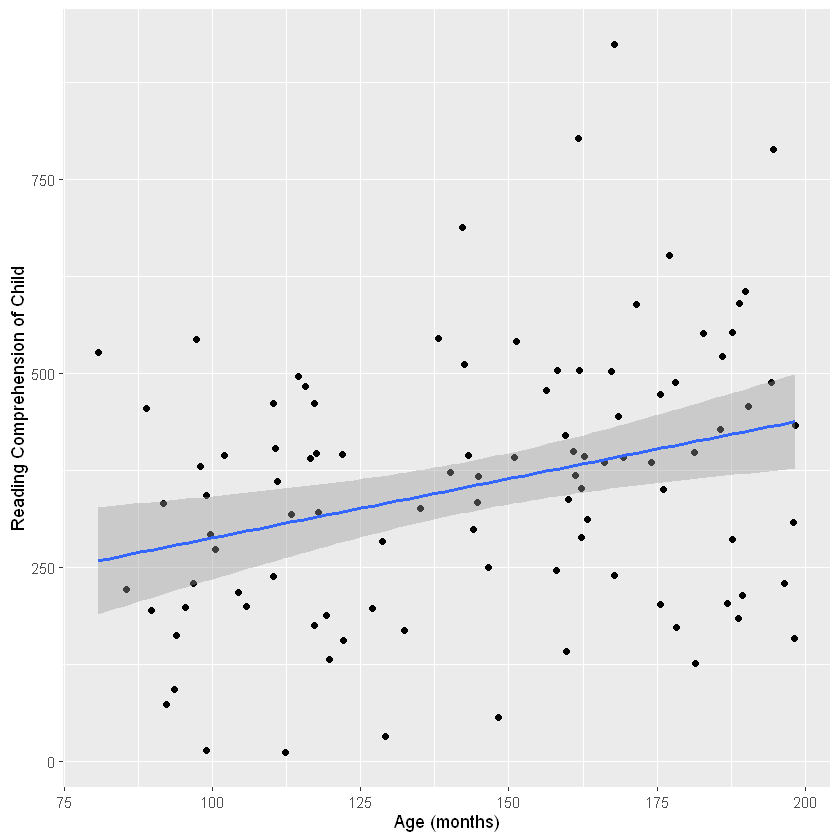

In [31]:
ggplot(dat, aes (x = age, y = c)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE) +
    labs(
        x = "Age (months)",
        y = "Reading Comprehension of Child"
        )

b) Plot the relationship between reading experience, age, and reading comprehension.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"The following aesthetics were dropped during statistical transformation: colour.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?"


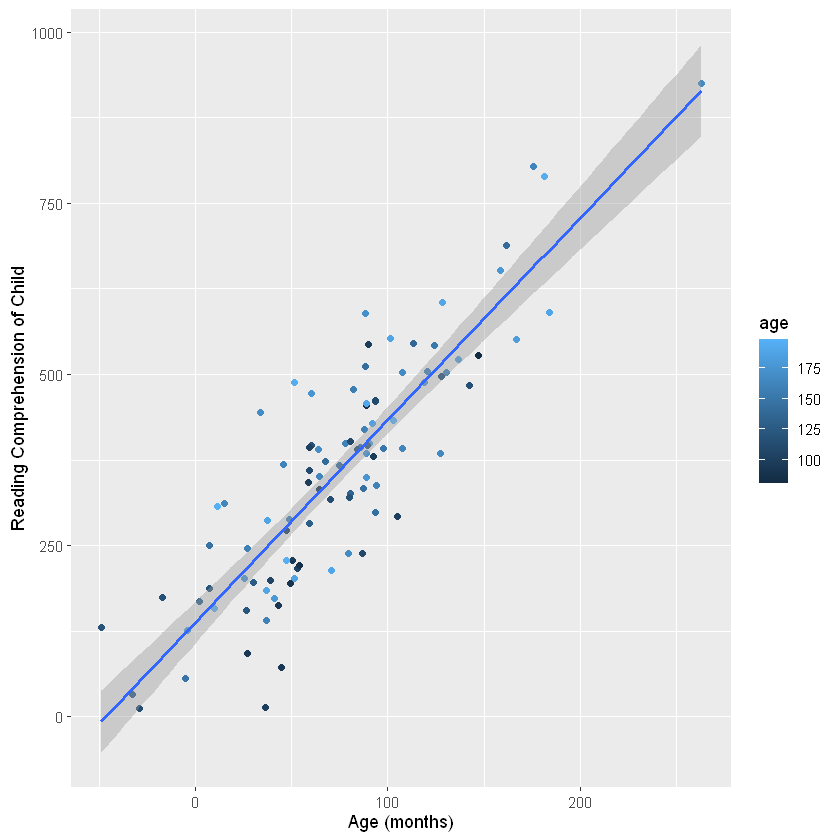

In [32]:
ggplot(dat, aes (x = x, y = c , color = age)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE) +
    labs(
        x = "Age (months)",
        y = "Reading Comprehension of Child"
        )

---
## 3. Mediation Analysis (4 points)

Load the `mediation` library.

In [35]:
install.packages("mediation") # uncomment to install the mediation package. 
library(mediation)
library(MASS)

Warning message:
"package 'mediation' is in use and will not be installed"


Use the `mediate` function to determine whether `x` mediates the relationship between `age` and `c`. Use `summary()` to print the model results. *Hint: see the mediation and moderation tutorial.*

In [37]:
fitM <- lm(x ~ age, data = dat)
fitY <- lm(c ~ age + x, data = dat)
summary(fitM)
summary(fitY)

fitMed <- mediate(fitM, fitY, treat = "age", mediator = "x")
summary(fitMed)


Call:
lm(formula = x ~ age, data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-115.054  -32.013    1.203   27.040  182.382 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)  30.4596    21.5819   1.411   0.1613  
age           0.3000     0.1455   2.062   0.0418 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 49.63 on 98 degrees of freedom
Multiple R-squared:  0.04158,	Adjusted R-squared:  0.03181 
F-statistic: 4.252 on 1 and 98 DF,  p-value: 0.04185



Call:
lm(formula = c ~ age + x, data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-204.178  -50.242    3.398   61.368  187.490 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  48.0681    36.7822   1.307  0.19436    
age           0.6683     0.2507   2.665  0.00901 ** 
x             2.8605     0.1704  16.783  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 83.74 on 97 degrees of freedom
Multiple R-squared:  0.7676,	Adjusted R-squared:  0.7628 
F-statistic: 160.2 on 2 and 97 DF,  p-value: < 2.2e-16



Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

               Estimate 95% CI Lower 95% CI Upper p-value    
ACME            0.85788      0.08812      1.60366   0.024 *  
ADE             0.67824      0.18875      1.17768   0.008 ** 
Total Effect    1.53612      0.65150      2.42698  <2e-16 ***
Prop. Mediated  0.55651      0.12269      0.83226   0.024 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Sample Size Used: 100 


Simulations: 1000 


---
## 5. Reflection (1 point)
How do you interpret these results? Why do you think the analysis yielded this result?

### c is reading comprehension, x is word reading experience

>The first model shows that age significantly predicts word reading experience (x) with a p-value of 0.042. The second model shows that both age (p = 0.009) and word reading experience (p < 0.001) significantly predict reading comprehension (c). The mediation analysis shows a significant indirect effect (ACME = 0.086, p = 0.024), meaning word reading experience (x) significantly mediates the relationship between age and reading comprehension (c).
>
>
> The direct effect of age on reading comprehension remains significant (ADE = 0.068, p = 0.008), showimg some mediationn independent of word reading experience. Approximately 55.7% of the total effect of age on reading comprehension is explained through word reading experience.

**DUE:** 5pm EST, March 26, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*